AI Complaint Intelligence System

In [47]:
import pandas as pd
import numpy as np
import warnings 

warnings.filterwarnings('ignore')

In [48]:
df = pd.read_csv('complaints_processed.csv')

In [49]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [50]:
df.head()

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [51]:
df['product'].value_counts()

product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64

In [52]:
df.isnull().sum()

product       0
narrative    10
dtype: int64

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   product    162421 non-null  str  
 1   narrative  162411 non-null  str  
dtypes: str(2)
memory usage: 96.1 MB


In [54]:
df.dropna(subset=['narrative'], inplace=True)

In [55]:
df.isnull().sum()

product      0
narrative    0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(37735)

In [57]:
df.drop_duplicates(inplace= True)

In [58]:
df.shape

(124676, 2)

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.head(10)

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...
5,credit_reporting,payment history missing credit report made mis...
6,credit_reporting,va date complaint experian credit bureau invol...
7,credit_reporting,account reported abbreviated name full name se...
8,credit_reporting,account reported abbreviated name full name se...
9,credit_reporting,usdoexxxx account reported abbreviated name fu...


In [61]:
df = df[df['narrative'].str.len() >= 10]

In [62]:
df.shape

(124633, 2)

Text Cleaning

Lower Case

In [65]:
df['narrative'] = df['narrative'].apply(lambda x : x.lower())

remove Punctuations

In [66]:
import string

def remove_punc(txt) : 
    return txt.translate(str.maketrans('', '', string.punctuation))

In [ ]:
df['narrative'] = df['narrative'].apply(remove_punc)

Remove URL & Links

In [69]:
import re

def remove_url(txt):
    return re.sub(r'http\S+|www\S+', '',txt)

df['narrative'] = df['narrative'].apply(remove_url)

remove HTML tags

In [ ]:
import re 

def remove_html(txt):
    return  re.sub(r'<.*?>', '', txt)

In [72]:
df['narrative'] = df['narrative'].apply(remove_html)

remove emoji

In [73]:
def remove_emoji(txt):
    new = ''
    for i in txt:
        if i.isascii():
            new += i

    return new

df['narrative'] = df['narrative'].apply(remove_emoji)

Remove Stop words

In [74]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [75]:
stop_words = set(stopwords.words('english'))

In [76]:
def remove(txt):
    words = word_tokenize(txt)
    cleaned = []
    for i in words:
        if not i in stop_words:
            cleaned.append(i)

    return ' '.join(cleaned)

In [77]:
df['narrative'] = df['narrative'].apply(remove)

In [78]:
df.loc[1]['narrative']

'forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card provider company childrens place new york forever victoria secret original credit comenity bank lower limit began charge overage fee along late fee began pay close attention card find limit also changed well incurring overage late fee reached company comenity bank stated would change credit limit original limit reached told summit payment account corrected comenity bank credit card impacted credit score plummeted negative status im currently paying price due corruption affected detrimental way debt due company charging overage fee well late fee even initial credit limit fluctuating tremendously company charge major fee account willing correct account nervous said attorney reason im reaching im employee company ruining credit plz help name contact info thank'

EDA

In [79]:
df.shape

(124633, 2)

In [80]:
df['product'].value_counts()

product
credit_reporting       56283
debt_collection        21106
mortgages_and_loans    18758
credit_card            15023
retail_banking         13463
Name: count, dtype: int64

In [81]:
df['narrative'].str.len().describe()

count    124633.000000
mean        633.501079
std         832.494641
min          10.000000
25%         219.000000
50%         414.000000
75%         752.000000
max       20596.000000
Name: narrative, dtype: float64

ML

In [82]:
X = df['narrative']
y = df['product']

In [83]:
from sklearn.model_selection import train_test_split

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    random_state= 42,
    test_size= 0.2,
    stratify= y
)

In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [88]:
tfidf = TfidfVectorizer()
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

In [89]:
print(X_train_tf.shape)
print(X_test_tf.shape)

(99706, 41543)
(24927, 41543)


First use Logisticregression model

In [90]:
from sklearn.linear_model import LogisticRegression

In [91]:
model_logistic = LogisticRegression(max_iter=1000)
model_logistic.fit(X_train_tf,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [92]:
y_pred_logistic = model_logistic.predict(X_test_tf)

In [98]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = round(accuracy_score(y_test, y_pred_logistic),4)
print('Accuracy =',accuracy)
print(classification_report(y_test, y_pred_logistic))

Accuracy = 0.8492
                     precision    recall  f1-score   support

        credit_card       0.80      0.78      0.79      3005
   credit_reporting       0.87      0.90      0.89     11257
    debt_collection       0.81      0.75      0.78      4221
mortgages_and_loans       0.85      0.84      0.84      3752
     retail_banking       0.86      0.88      0.87      2692

           accuracy                           0.85     24927
          macro avg       0.84      0.83      0.83     24927
       weighted avg       0.85      0.85      0.85     24927



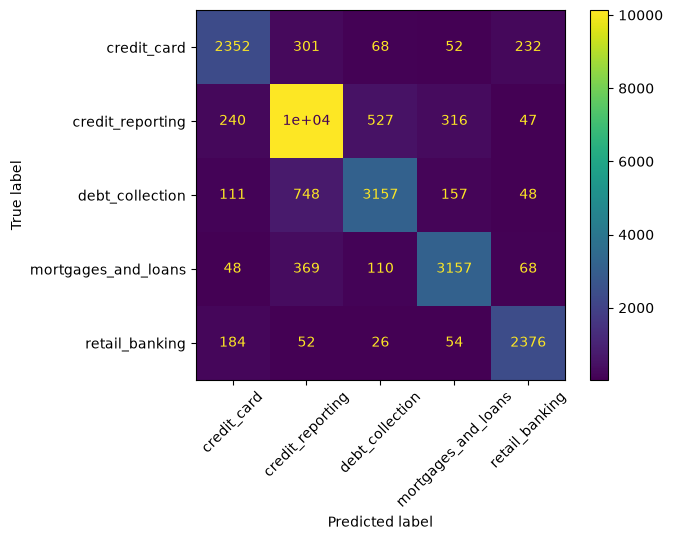

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_logistic.classes_
)

disp.plot(xticks_rotation=45)
plt.show()

Use second Model Linear SVM

In [101]:
from sklearn.svm import LinearSVC

In [102]:
model_svm = LinearSVC()
model_svm.fit(X_train_tf,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [103]:
y_pred_svm = model_svm.predict(X_test_tf)

In [104]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = round(accuracy_score(y_test, y_pred_svm),4)
print('Accuracy =',accuracy)
print(classification_report(y_test, y_pred_svm))

Accuracy = 0.8466
                     precision    recall  f1-score   support

        credit_card       0.80      0.77      0.78      3005
   credit_reporting       0.87      0.90      0.89     11257
    debt_collection       0.81      0.75      0.78      4221
mortgages_and_loans       0.84      0.83      0.84      3752
     retail_banking       0.85      0.88      0.86      2692

           accuracy                           0.85     24927
          macro avg       0.83      0.83      0.83     24927
       weighted avg       0.85      0.85      0.85     24927



Random Forest

In [107]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_tf, y_train)



,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [108]:
rf_pred = rf.predict(X_test_tf)

In [109]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.8404140089060055
                     precision    recall  f1-score   support

        credit_card       0.82      0.70      0.75      3005
   credit_reporting       0.83      0.96      0.89     11257
    debt_collection       0.88      0.67      0.76      4221
mortgages_and_loans       0.87      0.81      0.84      3752
     retail_banking       0.85      0.84      0.84      2692

           accuracy                           0.84     24927
          macro avg       0.85      0.79      0.82     24927
       weighted avg       0.84      0.84      0.84     24927

